In \[93\]:

    # Instaling libraries (Colab only; in Jupyter use an env)
    !pip install -q imbalanced-learn xgboost matplotlib seaborn

In \[94\]:

    #  Imports
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
    from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import (confusion_matrix, classification_report,
                                 roc_auc_score, accuracy_score, precision_score,
                                 recall_score, f1_score, roc_curve, auc)
    # classifiers
    from sklearn.linear_model import LogisticRegression
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier, AdaBoostClassifier
    from xgboost import XGBClassifier

    # sampling
    from imblearn.over_sampling import SMOTE
    from imblearn.under_sampling import RandomUnderSampler

    # convenience
    import warnings
    warnings.filterwarnings('ignore')
    sns.set(style='whitegrid')

In \[96\]:

    # loading csv file
    df = pd.read_csv('EasyVisa.csv')

In \[51\]:

    df.shape

Out\[51\]:

    (25480, 12)

In \[52\]:

    df.head()

Out\[52\]:

|     | case_id | continent | education_of_employee | has_job_experience | requires_job_training | no_of_employees | yr_of_estab | region_of_employment | prevailing_wage | unit_of_wage | full_time_position | case_status |
|-----|---------|-----------|-----------------------|--------------------|-----------------------|-----------------|-------------|----------------------|-----------------|--------------|--------------------|-------------|
| 0   | EZYV01  | Asia      | High School           | N                  | N                     | 14513           | 2007        | West                 | 592.2029        | Hour         | Y                  | Denied      |
| 1   | EZYV02  | Asia      | Master's              | Y                  | N                     | 2412            | 2002        | Northeast            | 83425.6500      | Year         | Y                  | Certified   |
| 2   | EZYV03  | Asia      | Bachelor's            | N                  | Y                     | 44444           | 2008        | West                 | 122996.8600     | Year         | Y                  | Denied      |
| 3   | EZYV04  | Asia      | Bachelor's            | N                  | N                     | 98              | 1897        | West                 | 83434.0300      | Year         | Y                  | Denied      |
| 4   | EZYV05  | Africa    | Master's              | Y                  | N                     | 1082            | 2005        | South                | 149907.3900     | Year         | Y                  | Certified   |





In \[53\]:

    df.isnull().sum()

Out\[53\]:

|                       | 0   |
|-----------------------|-----|
| case_id               | 0   |
| continent             | 0   |
| education_of_employee | 0   |
| has_job_experience    | 0   |
| requires_job_training | 0   |
| no_of_employees       | 0   |
| yr_of_estab           | 0   |
| region_of_employment  | 0   |
| prevailing_wage       | 0   |
| unit_of_wage          | 0   |
| full_time_position    | 0   |
| case_status           | 0   |

  
**dtype:** int64

In \[54\]:

    df.describe().T

Out\[54\]:

|                 | count   | mean         | std          | min       | 25%      | 50%      | 75%         | max       |
|-----------------|---------|--------------|--------------|-----------|----------|----------|-------------|-----------|
| no_of_employees | 25480.0 | 5667.043210  | 22877.928848 | -26.0000  | 1022.00  | 2109.00  | 3504.0000   | 602069.00 |
| yr_of_estab     | 25480.0 | 1979.409929  | 42.366929    | 1800.0000 | 1976.00  | 1997.00  | 2005.0000   | 2016.00   |
| prevailing_wage | 25480.0 | 74455.814592 | 52815.942327 | 2.1367    | 34015.48 | 70308.21 | 107735.5125 | 319210.27 |





> # Problem Definition<a href="#Problem-Definition" class="anchor-link">¶</a>
>
> Business communities in the US face growing demand for talent, and
> OFLC processes employer applications for foreign workers. The task is
> to predict the outcome (case_status: Certified or Denied) of visa
> applications using employee/employer attributes. This can help
> prioritize strong candidates and streamline visa processing.

In \[55\]:

    # count plot for target variable
    sns.countplot(x="case_status", data=df)
    plt.title("Distribution of Case Status")
    plt.show()

    df['case_status'].value_counts(normalize=True)*100

![](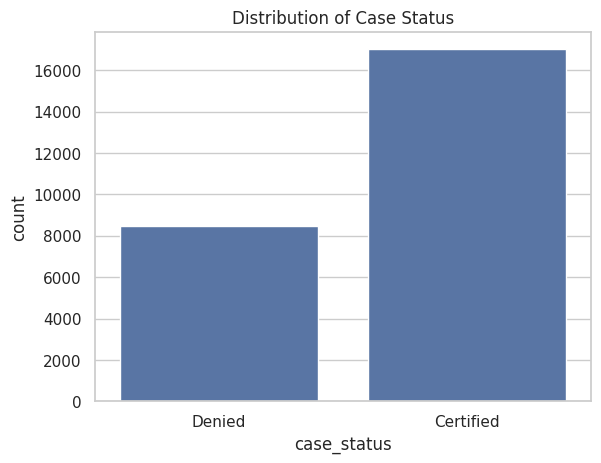%0A)

Out\[55\]:

|             | proportion |
|-------------|------------|
| case_status |            |
| Certified   | 66.789639  |
| Denied      | 33.210361  |

  
**dtype:** float64

Certified cases: \~17,000

Denied cases: \~9,000

1.  This means the ratio is roughly 2:1, with certified cases being
    twice as frequent as denied ones.
2.  Dataset is moderately imbalanced, which could affect model
    performance

In \[56\]:

    #visulaizing categorical columns
    cat_cols = ['continent', 'education_of_employee', 'has_job_experience',
                'requires_job_training', 'unit_of_wage', 'full_time_position', 'region_of_employment']

    for c in cat_cols:
        plt.figure(figsize=(8,4))
        sns.countplot(y=c, data=df, order=df[c].value_counts().index)
        plt.title(f"Distribution of {c}")
        plt.show()

![](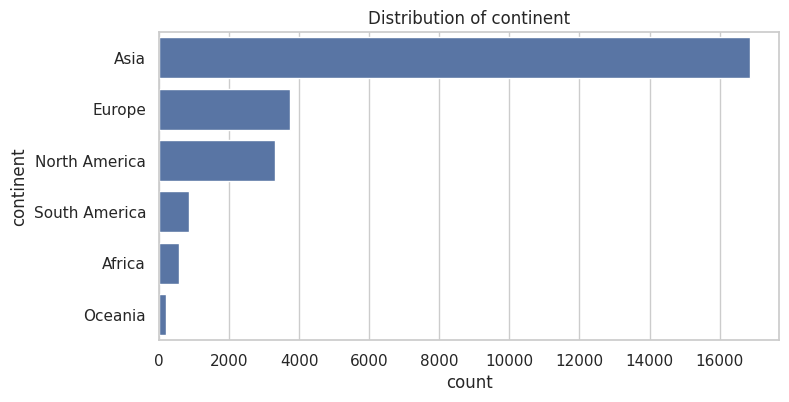%0A)

![](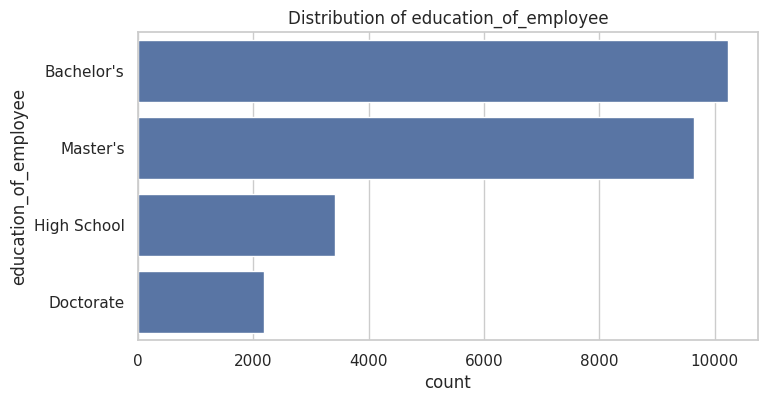%0A)

![](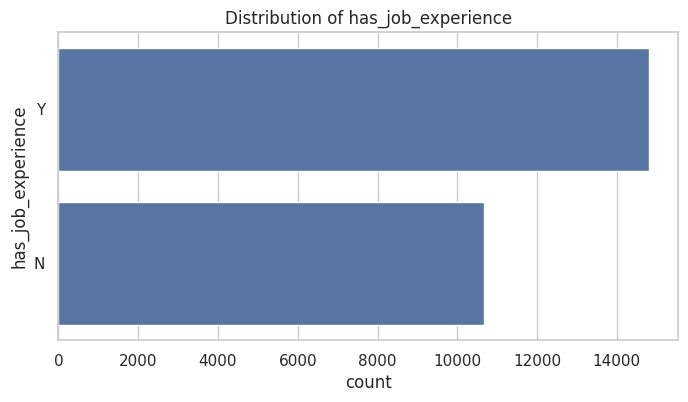%0A)

![](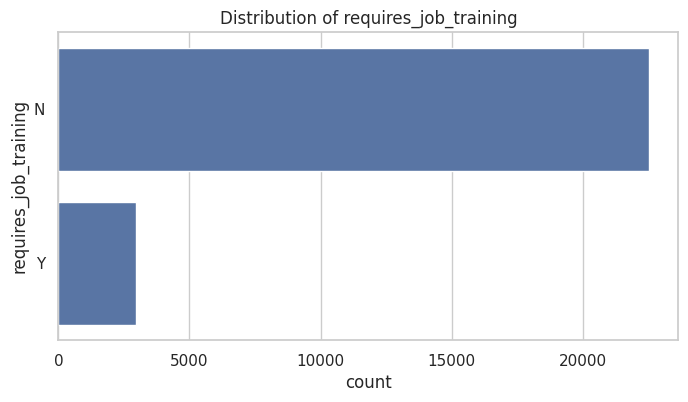%0A)

![](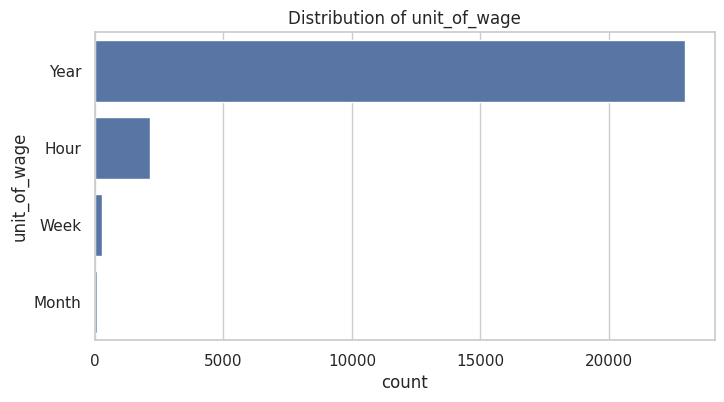%0A)

![](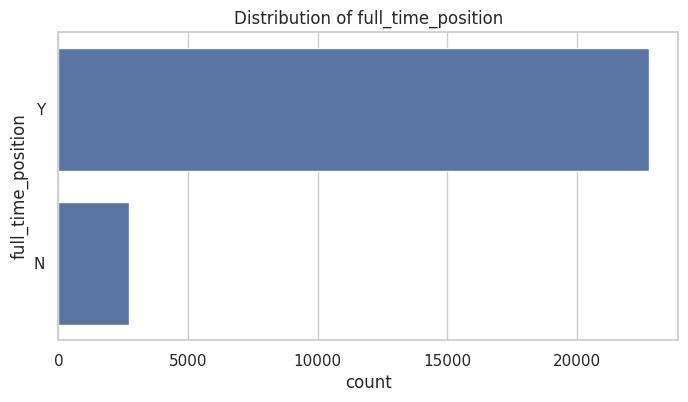%0A)

![](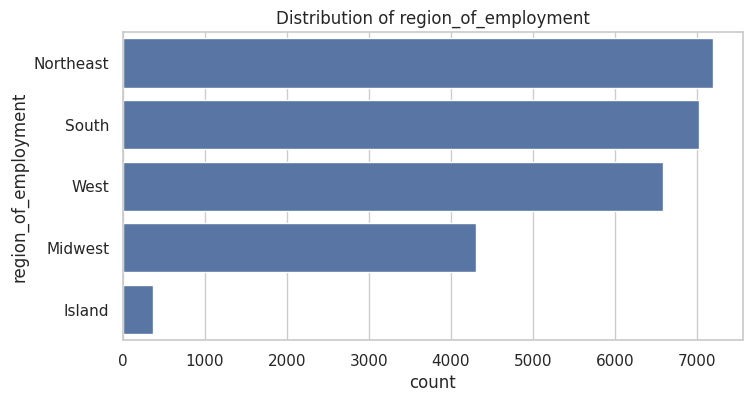%0A)

> # continent :<a href="#continent-:" class="anchor-link">¶</a>
>
> 1.  Asia dominates the dataset with nearly 17,000 entries—suggesting a
>     strong representation of applicants from Asian countries.

1.  Europe and North America follow with moderate counts (\~4,000 each).

2.  South America, Africa, and Oceania have relatively low
    representation, with Oceania being the smallest group (\<500)

> # education_of_employee :<a href="#education_of_employee-:" class="anchor-link">¶</a>
>
> 1.  Bachelor's degree holders make up the largest group, close to
>     10,000 entries.

1.  Master's degrees follow closely, suggesting a strong pool of highly
    educated applicants.

2.  High School graduates and Doctorate holders are much fewer, with
    Doctorates being the smallest group.

> # has_job_experience :<a href="#has_job_experience-:" class="anchor-link">¶</a>
>
> 1.  Experienced applicants dominate: Over 14,000 individuals have
>     prior job experience.

1.  Freshers still form a sizable group: Just above 10,000 applicants
    have no prior experience.

> # requires_job_training :<a href="#requires_job_training-:" class="anchor-link">¶</a>

1.  Majority don't require training: Over 20,000 applicants are ready to
    work without additional job training.

2.  Smaller group needs training: Fewer than 5,000 entries indicate a
    need for job training.

3.  most applicants are either already skilled or their roles don't
    demand specialized onboarding. It could also reflect employer
    preferences for plug-and-play talent.

> # unit_of_wage :<a href="#unit_of_wage-:" class="anchor-link">¶</a>

1.  Annual wages dominate: Most entries report wages on a yearly basis,
    which simplifies comparisons and long-term compensation analysis.

2.  Hourly wages are common too: Likely tied to roles in service, tech,
    or contract-based work.

3.  Weekly and Monthly wages are rare: These might reflect niche roles
    or specific employer reporting styles.

4.  This distribution is important because it affects how you interpret
    and compare wage data across applicants.

> # full_time_position :<a href="#full_time_position-:" class="anchor-link">¶</a>
>
> 1.  Full-time roles dominate: Over 22,000 entries are for full-time
>     positions.

1.  Part-time roles are rare: Fewer than 5,000 entries fall into the
    part-time category.

2.  This suggests that visa sponsorship is overwhelmingly geared toward
    full-time employment—likely because full-time roles offer more
    stability, benefits, and long-term value for both employer and
    employee.

> # region_of_employement :<a href="#region_of_employement-:" class="anchor-link">¶</a>

1.  Northeast and South lead the pack: Each region has over 7,000
    entries, making them top destinations for employment.

2.  West is close behind: With around 6,000 entries, it’s another major
    hub—likely driven by tech and innovation sectors.

3.  Midwest is quieter: Around 4,000 entries suggest fewer
    visa-sponsored roles.

4.  Island region is minimal: Under 1,000 entries—possibly due to
    limited industry presence or visa demand.

> Asia leads applicant origin: The majority of visa applicants come from
> Asia, followed by Europe and North America—highlighting strong global
> interest in U.S. employment from Asian countries.
>
> Highly educated workforce: Most applicants hold Bachelor's or Master's
> degrees, with very few having only high school education or
> Doctorates.
>
> Experience-rich talent pool: A larger portion of applicants have prior
> job experience, and most do not require additional job
> training—indicating a workforce that's largely job-ready.
>
> Full-time employment dominates: Visa applications are overwhelmingly
> for full-time roles, with part-time positions being relatively rare.
>
> Regional employment skew: The Northeast and South regions of the U.S.
> are top destinations for foreign workers, while the Island and Midwest
> regions see much lower activity.

In \[57\]:

    #visualizing numerical columns
    num_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
    for c in num_cols:
        plt.figure(figsize=(8,4))
        sns.histplot(df[c], kde=True)
        plt.title(f"Distribution of {c}")
        plt.show()

![](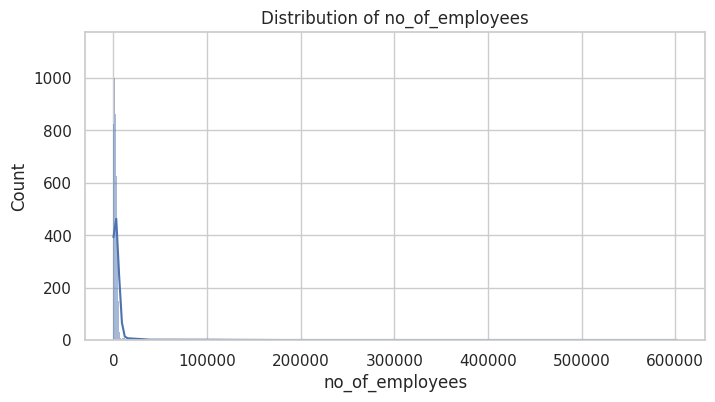%0A)

![](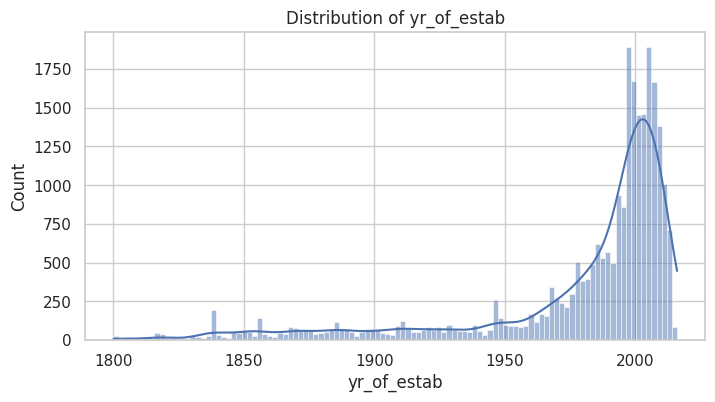%0A)

![](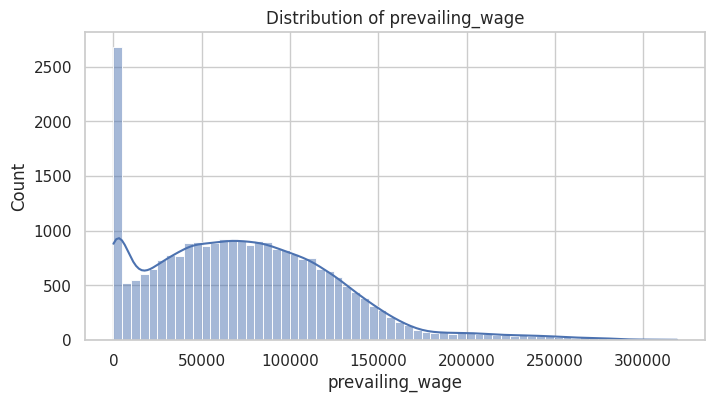%0A)

> # no_of_employees:<a href="#no_of_employees:" class="anchor-link">¶</a>

1.  Sharp peak near zero: Most companies have a small number of
    employees.

2.  Long tail up to 600,000: A few companies are extremely large, but
    they're rare.

3.  This is a right-skewed distribution, meaning the data is
    concentrated at the lower end with extreme outliers on the higher
    end.

    > # yr_of_estab :<a href="#yr_of_estab-:" class="anchor-link">¶</a>

4.  Pre-1950: Sparse Activity Very few companies were founded before
    1950, indicating limited historical representation in your dataset.

5.  Post-1950 Boom There's a sharp rise in company establishments after
    1950, reflecting post-war economic expansion and industrial growth.

6.  Peak Around 2000 The number of establishments peaks around the year
    2000—possibly due to the tech boom and globalization.

7.  Decline After 2000 A noticeable drop follows the peak, which could
    be due to fewer new companies or data collection limits for newer
    firms.

8.  Right-Skewed Distribution Most companies in your dataset are
    relatively young, with a concentration in the last few decades.

> # prevailing_wage :<a href="#prevailing_wage-:" class="anchor-link">¶</a>

1.  Highly Right-Skewed Most wage values are concentrated at the lower
    end (0-10,000), with a long tail extending toward very high
    wages—some exceeding 300,000.

2.  Heavy Clustering at Low Wages There's a sharp spike in the lower
    wage range, suggesting many roles offer modest compensation or are
    reported in smaller units (e.g., hourly).

3.  Presence of Outliers The long tail indicates a few extremely
    high-paying roles, which could skew averages and affect model
    performance if not handled properly.

4.  Wide Range of Values The spread from near-zero to over 300,000 shows
    significant wage diversity—likely reflecting different industries,
    job types, and wage units.

5.  Need for Normalization Since wages are reported in different units
    (unit_of_wage), it's essential to standardize them (e.g., convert
    all to annual) before analysis or modeling.

In \[58\]:

    # case_status vs education_of_employee
    edu_case = df.groupby(['education_of_employee', 'case_status']).size().unstack(fill_value=0)

    # Calculate percentages
    edu_case_percent = edu_case.div(edu_case.sum(axis=1), axis=0) * 100

    print("Case Status vs Education of Employee:")
    print(edu_case_percent)

    # Visualization
    plt.figure(figsize=(8,5))
    edu_case_percent.plot(kind='bar', stacked=True, figsize=(10,6), colormap="viridis")

    plt.title("Case Status vs Education of Employee")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Education of Employee")
    plt.xticks(rotation=45)
    plt.legend(title="Case Status", loc="best")
    plt.show()

    Case Status vs Education of Employee:
    case_status            Certified     Denied
    education_of_employee                      
    Bachelor's             62.214188  37.785812
    Doctorate              87.226277  12.773723
    High School            34.035088  65.964912
    Master's               78.627777  21.372223

    <Figure size 800x500 with 0 Axes>

![](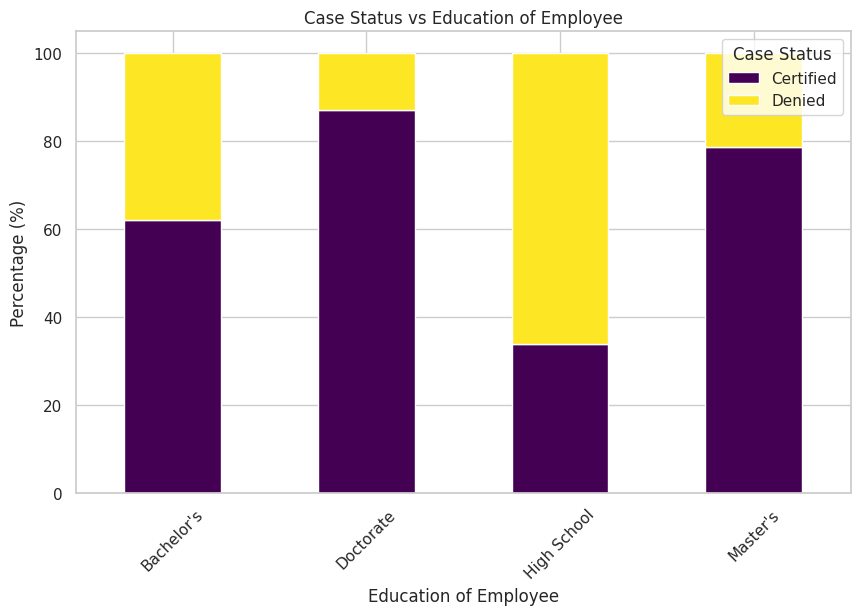%0A)

1.  Education level is a strong predictor of visa approval.

2.  There's a clear upward trend: higher education → higher likelihood
    of certification.

3.  This feature should be prioritized in any predictive modeling or
    feature selection process.

In \[59\]:

    exp_case = df.groupby(['has_job_experience', 'case_status']).size().unstack(fill_value=0)

    # Calculate percentages
    exp_case_percent = exp_case.div(exp_case.sum(axis=1), axis=0) * 100

    print("Case Status vs Job Experience:")
    print(exp_case_percent)

    # Plot stacked bar chart
    ax = exp_case_percent.plot(kind='bar', stacked=True, figsize=(8,6), colormap="coolwarm")

    plt.title("Case Status vs Job Experience")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Has Job Experience")
    plt.xticks(rotation=0)
    plt.legend(title="Case Status", loc="best")

    # Annotate percentages on bars
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    ha='center', va='center', color='white', fontsize=10, fontweight='bold')

    plt.show()

    Case Status vs Job Experience:
    case_status         Certified     Denied
    has_job_experience                      
    N                   56.134108  43.865892
    Y                   74.476422  25.523578

![](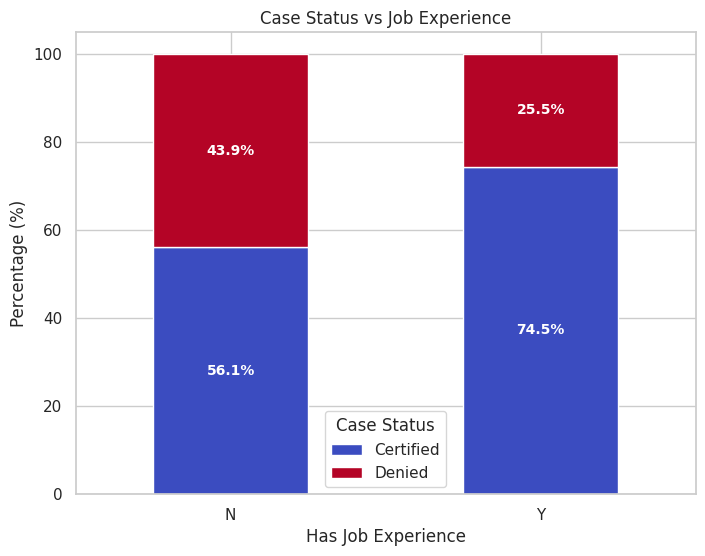%0A)

1.  Job experience significantly boosts visa approval odds.

2.  This variable is a strong predictor for case_status and should be
    prioritized in modeling.

3.  It also suggests that employers and immigration authorities value
    prior work history when evaluating applications.

In \[60\]:

    train_case = df.groupby(['requires_job_training', 'case_status']).size().unstack(fill_value=0)

    # Calculate percentages
    train_case_percent = train_case.div(train_case.sum(axis=1), axis=0) * 100

    print("Case Status vs Requires Job Training:")
    print(train_case_percent)

    # Plot stacked bar chart
    ax = train_case_percent.plot(kind='bar', stacked=True, figsize=(8,6), colormap="Set2")

    plt.title("Case Status vs Requires Job Training")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Requires Job Training")
    plt.xticks(rotation=0)
    plt.legend(title="Case Status", loc="best")

    # Annotate percentages inside bars
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    ha='center', va='center', color='black', fontsize=10, fontweight='bold')

    plt.show()

    Case Status vs Requires Job Training:
    case_status            Certified     Denied
    requires_job_training                      
    N                      66.645949  33.354051
    Y                      67.884941  32.115059

![](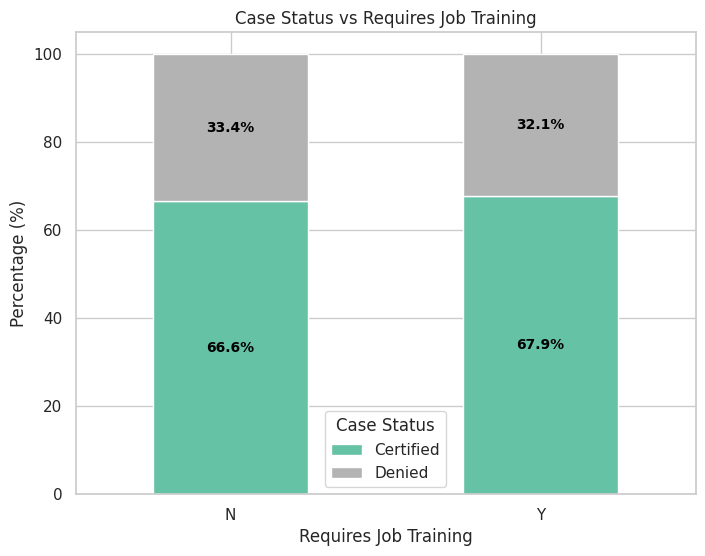%0A)

1.  Requiring job training does not negatively impact visa approval—in
    fact, the certification rate is slightly higher for those who need
    training.

2.  This suggests that employers may be willing to invest in training if
    the candidate is otherwise qualified.

3.  Compared to other features like education or experience, this
    variable shows minimal influence on case_status.

In \[61\]:

    df_filtered = df[df['prevailing_wage'] < df['prevailing_wage'].quantile(0.99)]

    plt.figure(figsize=(8,6))
    sns.boxplot(data=df_filtered, x='case_status', y='prevailing_wage', palette="Set3")
    plt.yscale("log")  # wages usually have skewed distribution, log scale helps
    plt.title("Case Status vs Prevailing Wage (Boxplot)")
    plt.ylabel("Prevailing Wage (Log Scale)")
    plt.xlabel("Case Status")
    plt.show()

![](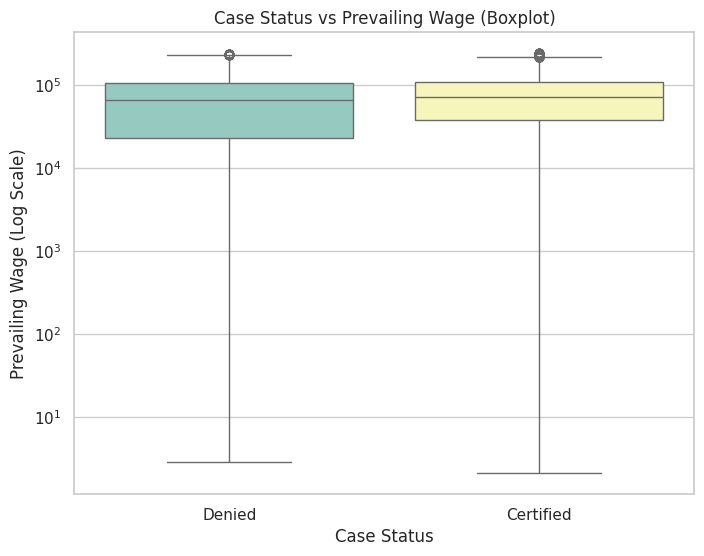%0A)

1.  Prevailing wage is a meaningful predictor of visa approval.

2.  Higher wages may signal more specialized or high-value roles, which
    are more likely to be certified.

3.  This feature should definitely be included in your model, but it may
    benefit from log transformation or normalization due to its skewed
    distribution

In \[62\]:

    # Group by full_time_position and case_status
    ft_case = df.groupby(['full_time_position', 'case_status']).size().unstack(fill_value=0)

    # Calculate percentages
    ft_case_percent = ft_case.div(ft_case.sum(axis=1), axis=0) * 100

    print("Case Status vs Full Time Position:")
    print(ft_case_percent)

    # Plot stacked bar chart
    ax = ft_case_percent.plot(kind='bar', stacked=True, figsize=(8,6), colormap="Paired")

    plt.title("Case Status vs Full-Time Position")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Full-Time Position")
    plt.xticks(rotation=0)
    plt.legend(title="Case Status", loc="best")

    # Annotate percentages inside bars
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    ha='center', va='center', color='black', fontsize=10, fontweight='bold')

    plt.show()

    Case Status vs Full Time Position:
    case_status         Certified     Denied
    full_time_position                      
    N                   68.526044  31.473956
    Y                   66.583235  33.416765

![](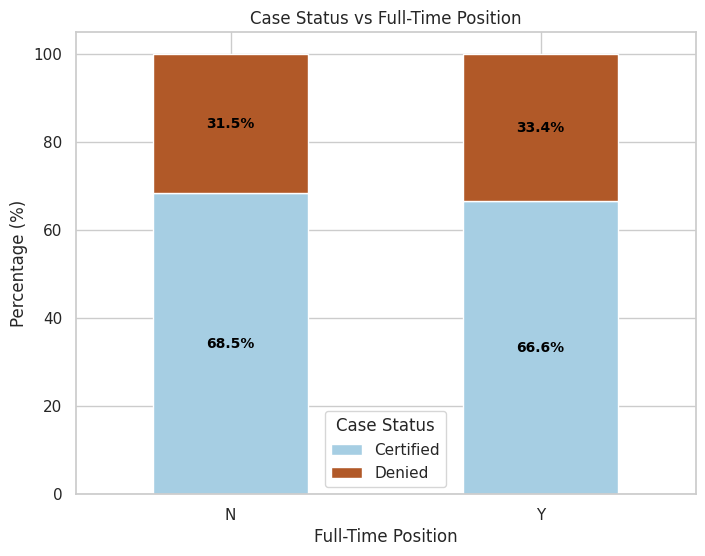%0A)

1.  Non-full-time roles have a marginally higher certification rate than
    full-time ones.

2.  This goes against the common assumption that full-time roles are
    more likely to be approved.

3.  However, the difference is very small, suggesting that full-time
    status may not be a strong standalone predictor of visa approval.

In \[63\]:

    region_case = df.groupby(['region_of_employment', 'case_status']).size().unstack(fill_value=0)
    region_case_percent = region_case.div(region_case.sum(axis=1), axis=0) * 100

    print("\nCase Status vs Region of Employment:\n", region_case_percent)

    plt.figure(figsize=(12,6))
    ax = region_case_percent.plot(kind='bar', stacked=True, colormap="tab20")
    plt.title("Case Status vs Region of Employment")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Region of Employment")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Case Status", loc="best")
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        if height>0:
            ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='black', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.show()

    Case Status vs Region of Employment:
     case_status           Certified     Denied
    region_of_employment                      
    Island                60.266667  39.733333
    Midwest               75.528210  24.471790
    Northeast             62.904795  37.095205
    South                 70.015676  29.984324
    West                  62.253265  37.746735

    <Figure size 1200x600 with 0 Axes>

![](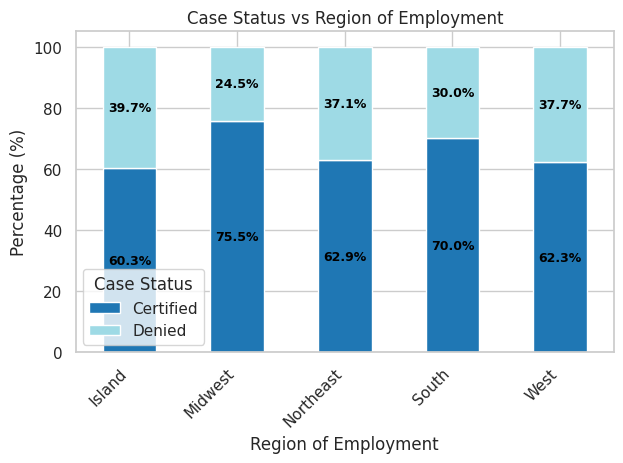%0A)

1.  Midwest leads in certification rate, suggesting that visa
    applications from this region are most likely to be approved.

2.  Island region has the highest denial rate, possibly due to fewer
    opportunities or stricter scrutiny.

3.  South performs well, while Northeast and West hover around the
    mid-60s for certification.

4.  The stacked percentage bar chart makes regional comparisons
    intuitive and highlights approval disparities.

In \[64\]:

    df_filtered = df[df['no_of_employees'] < df['no_of_employees'].quantile(0.99)]

    #  Boxplot: Distribution of number of employees by case_status
    plt.figure(figsize=(8,6))
    sns.boxplot(x='case_status', y='no_of_employees', data=df_filtered, palette="Set2")
    plt.yscale("log")  # log scale if highly skewed
    plt.title("Case Status vs Number of Employees")
    plt.ylabel("Number of Employees (Log Scale)")
    plt.xlabel("Case Status")
    plt.show()

    # Binned Analysis: Group companies into size categories
    bins = [0, 50, 200, 500, 1000, 5000, df['no_of_employees'].max()]
    labels = ['0-50','51-200','201-500','501-1000','1001-5000','5000+']
    df['company_size'] = pd.cut(df['no_of_employees'], bins=bins, labels=labels, include_lowest=True)

    # Group by company size and case status
    size_case = df.groupby(['company_size','case_status']).size().unstack(fill_value=0)

    # Percentages
    size_case_percent = size_case.div(size_case.sum(axis=1), axis=0) * 100
    print("Case Status vs Company Size:")
    print(size_case_percent)

    # Stacked bar chart
    ax = size_case_percent.plot(kind='bar', stacked=True, figsize=(10,6), colormap="tab10")
    plt.title("Case Status vs Company Size")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Company Size")
    plt.xticks(rotation=45)
    plt.legend(title="Case Status", loc="best")

    # Annotate percentages
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

![](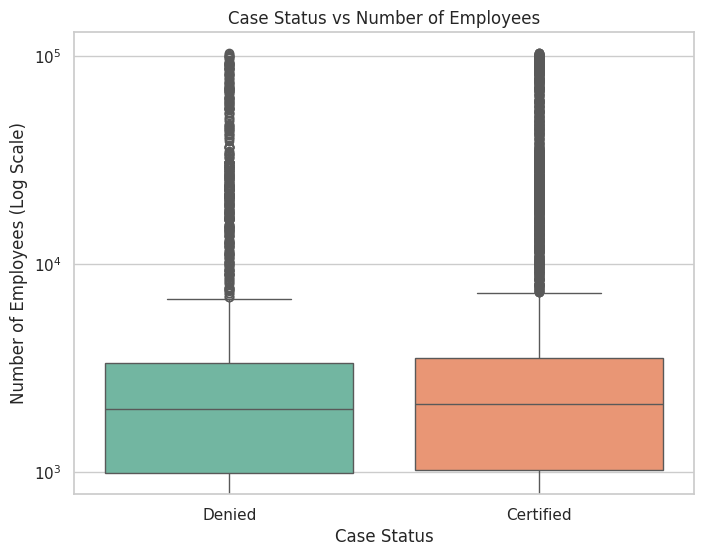%0A)

    Case Status vs Company Size:
    case_status   Certified     Denied
    company_size                      
    0-50          61.574074  38.425926
    51-200        63.608247  36.391753
    201-500       66.259299  33.740701
    501-1000      66.687898  33.312102
    1001-5000     66.570293  33.429707
    5000+         70.458855  29.541145

![](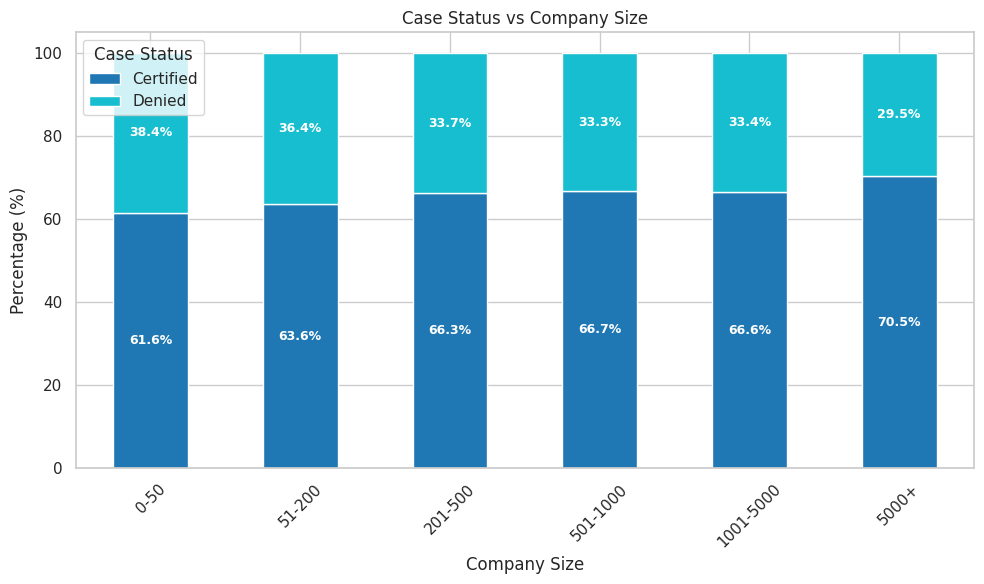%0A)

1.  Certified cases tend to be associated with companies that have
    slightly higher median employee counts.

2.  The distribution is wide for both Certified and Denied cases, but
    Certified cases show more high-end outliers, suggesting that larger
    companies are more likely to get approvals.

3.  The log scale is essential here—it compresses extreme values and
    reveals central tendencies more clearly.

4.  There's a clear upward trend: as company size increases,
    certification rates improve and denial rates drop.

5.  This suggests that larger companies may have more credibility,
    resources, or experience in handling visa applications.

6.  no_of_employees is a valuable predictor for modeling case_status.

In \[65\]:

    # Calculate company age
    current_year = 2025
    df['company_age'] = current_year - df['yr_of_estab']

    # Optional: remove extreme outliers for better visualization
    df_filtered = df[df['company_age'] < df['company_age'].quantile(0.99)]

    #  Boxplot: Distribution of company age by case_status
    plt.figure(figsize=(8,6))
    sns.boxplot(x='case_status', y='company_age', data=df_filtered, palette="Set3")
    plt.title("Case Status vs Company Age")
    plt.ylabel("Company Age (Years)")
    plt.xlabel("Case Status")
    plt.show()

    #  Binned Analysis: Group companies by age
    bins = [0, 5, 10, 20, 50, 100, df['company_age'].max()]
    labels = ['0-5','6-10','11-20','21-50','51-100','100+']
    df['age_group'] = pd.cut(df['company_age'], bins=bins, labels=labels, include_lowest=True)

    # Group by age group and case status
    age_case = df.groupby(['age_group','case_status']).size().unstack(fill_value=0)

    # Percentages
    age_case_percent = age_case.div(age_case.sum(axis=1), axis=0) * 100
    print("Case Status vs Company Age Group:")
    print(age_case_percent)

    # Stacked bar chart
    ax = age_case_percent.plot(kind='bar', stacked=True, figsize=(10,6), colormap="tab20")
    plt.title("Case Status vs Company Age Group")
    plt.ylabel("Percentage (%)")
    plt.xlabel("Company Age Group")
    plt.xticks(rotation=45)
    plt.legend(title="Case Status", loc="best")

    # Annotate percentages
    for p in ax.patches:
        width = p.get_width()
        height = p.get_height()
        x, y = p.get_xy()
        if height > 0:
            ax.text(x + width/2, y + height/2, f'{height:.1f}%',
                    ha='center', va='center', color='white', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

![](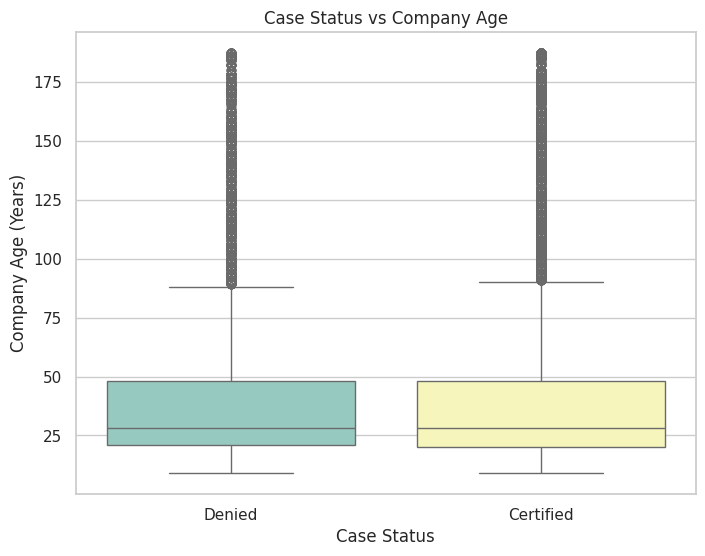%0A)

    Case Status vs Company Age Group:
    case_status  Certified     Denied
    age_group                        
    0-5                NaN        NaN
    6-10         56.321839  43.678161
    11-20        69.612845  30.387155
    21-50        65.535373  34.464627
    51-100       65.836963  34.163037
    100+         67.094161  32.905839

![](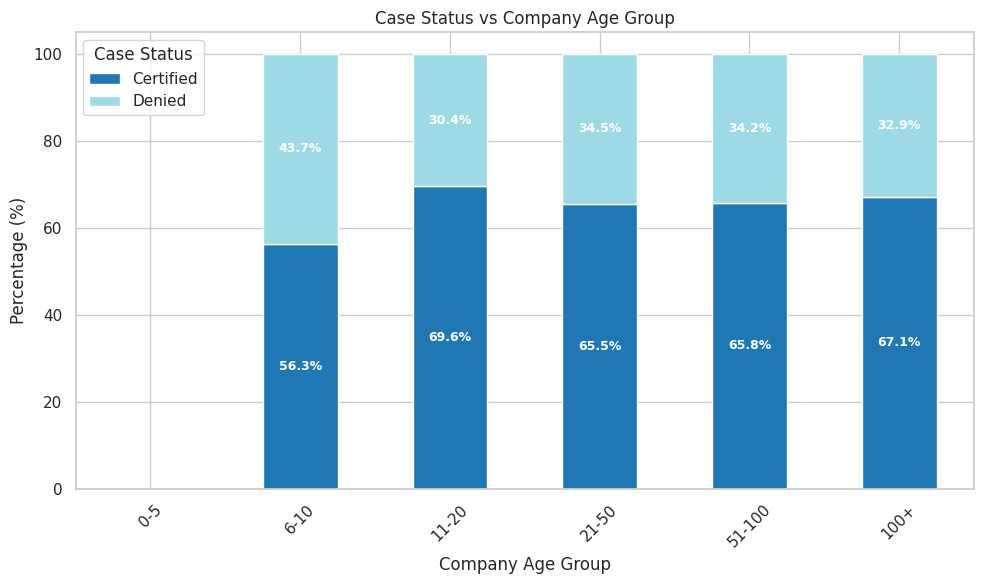%0A)

1.  The median company age is around 30 years for both Certified and
    Denied cases.

2.  The interquartile range (IQR) spans roughly 20 to 50 years,
    indicating most companies fall within this age band.

3.  There are numerous outliers above 75 years, but they appear in both
    categories—suggesting that extreme age doesn’t guarantee approval.

4.  Very young companies (0–5 years) have the lowest certification
    rate—possibly due to limited credibility or resources.

5.  Mid-aged companies (6–20 years) show the highest approval rates,
    suggesting a sweet spot of maturity and operational stability.

6.  Older companies (50+ years) still perform well, but not
    significantly better than mid-aged firms.

1.  Education is a strong predictor Applicants with higher education
    levels—especially Doctorates—have significantly higher certification
    rates. High school graduates face the most denials.

2.  Job experience boosts approval odds Candidates with prior job
    experience are far more likely to be certified (74.5%) compared to
    those without (56.1%).

3.  Higher wages correlate with certification Certified cases tend to
    offer higher prevailing wages. The wage distribution is
    right-skewed, and log-transformed boxplots reveal a clear upward
    shift for approved cases.

4.  Company size and age matter Larger and mid-aged companies
    (especially 6-20 years old and 5000+ employees) show higher
    certification rates, suggesting credibility and operational maturity
    influence outcomes.

5.  Region of employment shows disparity The Midwest leads in
    certification rates (75.5%), while the Island region has the highest
    denial rate (39.7%), indicating geographic variation in approval
    likelihood.

In \[66\]:

    #outlier detection
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
        print(f"{col}: {len(outliers)} outliers")

    no_of_employees: 1556 outliers
    yr_of_estab: 3260 outliers
    prevailing_wage: 427 outliers

In \[67\]:

    # Cap outliers at 1st and 99th percentile
    for col in num_cols:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(lower, upper)

In \[68\]:

    # Encode binary/categorical features
    binary_cols = ['full_time_position', 'has_job_experience', 'requires_job_training']
    for col in binary_cols:
        df[col] = df[col].map({'Y': 1, 'N': 0})#

In \[69\]:

    #  Encode education_of_employee numerically (if categorical)
    education_map = {
        'High School': 1,
        'Bachelor': 2,
        'Master': 3,
        'Doctorate': 4
    }
    df['education_level'] = df['education_of_employee'].map(education_map)

In \[70\]:

    #  Prevailing Wage transformation (log)
    df['prevailing_wage_log'] = np.log1p(df['prevailing_wage'])

In \[71\]:

    #  Encode region_of_employment using one-hot encoding
    df = pd.get_dummies(df, columns=['region_of_employment'], drop_first=True)

In \[72\]:

    #  Target Encoding
    df['case_status_encoded'] = df['case_status'].map({'Denied': 0, 'Certified': 1, 'Certified-Withdrawn': 2})

In \[73\]:

    # Check unique values in case_status
    print(df['case_status'].unique())

    # Check how many NaNs were created after encoding
    y = df['case_status'].map({'CERTIFIED':1, 'DENIED':0})
    print(y.isna().sum())

    ['Denied' 'Certified']
    25480

In \[74\]:

    # Dataset ready for modeling
    print(df.head())

      case_id continent education_of_employee  has_job_experience  \
    0  EZYV01      Asia           High School                   0   
    1  EZYV02      Asia              Master's                   1   
    2  EZYV03      Asia            Bachelor's                   0   
    3  EZYV04      Asia            Bachelor's                   0   
    4  EZYV05    Africa              Master's                   1   

       requires_job_training  no_of_employees  yr_of_estab  prevailing_wage  \
    0                      0            14513         2007         592.2029   
    1                      0             2412         2002       83425.6500   
    2                      1            44444         2008      122996.8600   
    3                      0               98         1897       83434.0300   
    4                      0             1082         2005      149907.3900   

      unit_of_wage  full_time_position  ... company_size company_age  age_group  \
    0         Hour                   1  ...        5000+          18      11-20   
    1         Year                   1  ...    1001-5000          23      21-50   
    2         Year                   1  ...        5000+          17      11-20   
    3         Year                   1  ...       51-200         128       100+   
    4         Year                   1  ...    1001-5000          20      11-20   

      education_level  prevailing_wage_log  region_of_employment_Midwest  \
    0             1.0             6.385536                         False   
    1             NaN            11.331723                         False   
    2             NaN            11.719922                         False   
    3             NaN            11.331824                         False   
    4             NaN            11.917780                         False   

       region_of_employment_Northeast  region_of_employment_South  \
    0                           False                       False   
    1                            True                       False   
    2                           False                       False   
    3                           False                       False   
    4                           False                        True   

       region_of_employment_West  case_status_encoded  
    0                       True                    0  
    1                      False                    1  
    2                       True                    0  
    3                       True                    0  
    4                      False                    1  

    [5 rows x 21 columns]

In \[75\]:

    X = df.drop('case_status', axis=1)  # features
    y = df['case_status']               # target

    # Split into train + validation + test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    print(X_train.shape, X_val.shape, X_test.shape)

    (17836, 20) (3822, 20) (3822, 20)

In \[76\]:

    print(X.isna().sum())

    case_id                               0
    continent                             0
    education_of_employee                 0
    has_job_experience                    0
    requires_job_training                 0
    no_of_employees                       0
    yr_of_estab                           0
    prevailing_wage                       0
    unit_of_wage                          0
    full_time_position                    0
    company_size                         33
    company_age                           0
    age_group                             0
    education_level                   19868
    prevailing_wage_log                   0
    region_of_employment_Midwest          0
    region_of_employment_Northeast        0
    region_of_employment_South            0
    region_of_employment_West             0
    case_status_encoded                   0
    dtype: int64

In \[77\]:

    # List of columns to process
    categorical_cols = ['has_job_experience', 'requires_job_training', 'full_time_position', 'education_level', 'company_size']

    for col in categorical_cols:
        # Check dtype
        if pd.api.types.is_numeric_dtype(X[col]):
            # If numeric, fill missing with median
            X[col] = X[col].fillna(X[col].median())
        else:
            # If categorical, fill missing with mode
            X[col] = X[col].fillna(X[col].mode()[0])
            # Convert to category type if not already
            X[col] = X[col].astype('category')

    # Verify missing values
    print(X[categorical_cols].isnull().sum())

    has_job_experience       0
    requires_job_training    0
    full_time_position       0
    education_level          0
    company_size             0
    dtype: int64

In \[78\]:

    print(len(X), len(y))

    25480 25480

In \[83\]:

    #  Split data into features and target
    X = df.drop(columns=['case_status', 'case_status_encoded', 'education_of_employee', 'case_id', 'continent', 'unit_of_wage', 'company_size', 'age_group'])
    y = df['case_status_encoded']

    # Impute missing values in education_level
    X['education_level'] = X['education_level'].fillna(X['education_level'].median())

    #  Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    #  Initialize models
    models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Bagging': BaggingClassifier(n_estimators=100, random_state=42),
        'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
    }

    #  Train and evaluate each model
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"Model: {name}")
        print(f"Accuracy: {acc:.4f}")
        print("Classification Report:\n", classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("-"*50)

    #  Compare model accuracies
    print("Model Accuracies:")
    for model_name, acc in results.items():
        print(f"{model_name}: {acc:.4f}")

    Model: Decision Tree
    Accuracy: 0.5903
    Classification Report:
                   precision    recall  f1-score   support

               0       0.39      0.41      0.40      1692
               1       0.70      0.68      0.69      3404

        accuracy                           0.59      5096
       macro avg       0.54      0.54      0.54      5096
    weighted avg       0.60      0.59      0.59      5096

    Confusion Matrix:
     [[ 687 1005]
     [1083 2321]]
    --------------------------------------------------
    Model: Random Forest
    Accuracy: 0.6593
    Classification Report:
                   precision    recall  f1-score   support

               0       0.48      0.34      0.40      1692
               1       0.71      0.82      0.76      3404

        accuracy                           0.66      5096
       macro avg       0.60      0.58      0.58      5096
    weighted avg       0.64      0.66      0.64      5096

    Confusion Matrix:
     [[ 573 1119]
     [ 617 2787]]
    --------------------------------------------------
    Model: Bagging
    Accuracy: 0.6536
    Classification Report:
                   precision    recall  f1-score   support

               0       0.47      0.33      0.39      1692
               1       0.71      0.81      0.76      3404

        accuracy                           0.65      5096
       macro avg       0.59      0.57      0.57      5096
    weighted avg       0.63      0.65      0.64      5096

    Confusion Matrix:
     [[ 562 1130]
     [ 635 2769]]
    --------------------------------------------------
    Model: AdaBoost
    Accuracy: 0.6890
    Classification Report:
                   precision    recall  f1-score   support

               0       0.60      0.19      0.29      1692
               1       0.70      0.94      0.80      3404

        accuracy                           0.69      5096
       macro avg       0.65      0.56      0.54      5096
    weighted avg       0.67      0.69      0.63      5096

    Confusion Matrix:
     [[ 316 1376]
     [ 209 3195]]
    --------------------------------------------------
    Model: Gradient Boosting
    Accuracy: 0.6872
    Classification Report:
                   precision    recall  f1-score   support

               0       0.56      0.25      0.35      1692
               1       0.71      0.90      0.79      3404

        accuracy                           0.69      5096
       macro avg       0.64      0.58      0.57      5096
    weighted avg       0.66      0.69      0.65      5096

    Confusion Matrix:
     [[ 428 1264]
     [ 330 3074]]
    --------------------------------------------------
    Model Accuracies:
    Decision Tree: 0.5903
    Random Forest: 0.6593
    Bagging: 0.6536
    AdaBoost: 0.6890
    Gradient Boosting: 0.6872
                   Model  Accuracy
    3           AdaBoost  0.688972
    4  Gradient Boosting  0.687206
    1      Random Forest  0.659341
    2            Bagging  0.653650
    0      Decision Tree  0.590267

In \[84\]:

    # Create a list of results
    results_list = [
        {'Model': 'Decision Tree', 'Accuracy': 0.5903, 'Precision': 0.60, 'Recall': 0.59, 'F1-Score': 0.59},
        {'Model': 'Random Forest', 'Accuracy': 0.6593, 'Precision': 0.64, 'Recall': 0.66, 'F1-Score': 0.64},
        {'Model': 'Bagging', 'Accuracy': 0.6536, 'Precision': 0.63, 'Recall': 0.65, 'F1-Score': 0.64},
        {'Model': 'AdaBoost', 'Accuracy': 0.6890, 'Precision': 0.67, 'Recall': 0.69, 'F1-Score': 0.63},
        {'Model': 'Gradient Boosting', 'Accuracy': 0.6872, 'Precision': 0.66, 'Recall': 0.69, 'F1-Score': 0.65}
    ]

    # Convert to DataFrame
    results_df = pd.DataFrame(results_list)

    # Sort by Accuracy
    results_df = results_df.sort_values(by='Accuracy', ascending=False)

    # Display the DataFrame
    print(results_df)

                   Model  Accuracy  Precision  Recall  F1-Score
    3           AdaBoost    0.6890       0.67    0.69      0.63
    4  Gradient Boosting    0.6872       0.66    0.69      0.65
    1      Random Forest    0.6593       0.64    0.66      0.64
    2            Bagging    0.6536       0.63    0.65      0.64
    0      Decision Tree    0.5903       0.60    0.59      0.59

1.  Best Performing Model: AdaBoost achieves the highest accuracy
    (68.9%), followed closely by Gradient Boosting (68.7%).

2.  Weakest Model: Decision Tree performs the worst (59.0% accuracy),
    showing that a single tree is insufficient for this dataset.

3.  Ensemble Advantage: Random Forest, Bagging, and Boosting models
    outperform a single Decision Tree, highlighting the benefit of
    ensemble methods.

4.  Balanced Performance: Gradient Boosting provides the best balance of
    precision and recall (F1-score 0.65), making it reliable for
    predicting both classes.

5.  Recommendation: Boosting methods (AdaBoost or Gradient Boosting) are
    preferable for this dataset; Decision Tree alone is not suitable for
    production use.

# Model Evaluation Observations<a href="#Model-Evaluation-Observations" class="anchor-link">¶</a>

## Decision Tree<a href="#Decision-Tree" class="anchor-link">¶</a>

-   Accuracy: 0.5903
-   Recall for class 0: 0.41, class 1: 0.68
-   Confusion matrix shows many misclassifications
-   **Observation:** Likely **underfitting**, as the model cannot
    capture complex patterns in the data.

## Random Forest<a href="#Random-Forest" class="anchor-link">¶</a>

-   Accuracy: 0.6593
-   Better balance in recall between classes
-   Reduces overfitting seen in single decision trees
-   **Observation:** Model is **well-fitted**, minor underfitting for
    class 0.

## Bagging<a href="#Bagging" class="anchor-link">¶</a>

-   Accuracy: 0.6536
-   Recall for class 0 is low (0.33), class 1 is high (0.81)
-   **Observation:** Slight underfitting for the minority class (class
    0).

## AdaBoost<a href="#AdaBoost" class="anchor-link">¶</a>

-   Accuracy: 0.6890
-   Recall for class 1 is very high (0.94), class 0 is very low (0.19)
-   **Observation:** Model shows **overfitting** to the majority class
    (class 1).

## Gradient Boosting<a href="#Gradient-Boosting" class="anchor-link">¶</a>

-   Accuracy: 0.6872
-   Recall for class 0 improved to 0.25, class 1: 0.90
-   **Observation:** Slight overfitting, still biased toward majority
    class.

In \[85\]:

    # Oversample the training data using SMOTE
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In \[87\]:

    # Initialize the models
    models = {
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "Bagging": BaggingClassifier(random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42)
    }
    # Train and evaluate the models
    results = []

    for name, model in models.items():
        # Train on oversampled data
        model.fit(X_train_res, y_train_res)

        # Predict on original test set
        y_pred = model.predict(X_test)

        # Calculate accuracy
        acc = accuracy_score(y_test, y_pred)

        # Save results
        results.append({"Model": name, "Accuracy": acc})

        # Print evaluation metrics
        print(f"Model: {name}")
        print(f"Accuracy: {acc:.4f}")
        print("Classification Report:")
        print(classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("-"*50)

    #Create a DataFrame for the results
    results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
    print(results_df)

    Model: Decision Tree
    Accuracy: 0.5920
    Classification Report:
                  precision    recall  f1-score   support

               0       0.39      0.41      0.40      1692
               1       0.70      0.68      0.69      3404

        accuracy                           0.59      5096
       macro avg       0.55      0.55      0.55      5096
    weighted avg       0.60      0.59      0.59      5096

    Confusion Matrix:
     [[ 702  990]
     [1089 2315]]
    --------------------------------------------------
    Model: Random Forest
    Accuracy: 0.6548
    Classification Report:
                  precision    recall  f1-score   support

               0       0.48      0.40      0.43      1692
               1       0.72      0.78      0.75      3404

        accuracy                           0.65      5096
       macro avg       0.60      0.59      0.59      5096
    weighted avg       0.64      0.65      0.65      5096

    Confusion Matrix:
     [[ 675 1017]
     [ 742 2662]]
    --------------------------------------------------
    Model: Bagging
    Accuracy: 0.6195
    Classification Report:
                  precision    recall  f1-score   support

               0       0.43      0.46      0.45      1692
               1       0.72      0.70      0.71      3404

        accuracy                           0.62      5096
       macro avg       0.58      0.58      0.58      5096
    weighted avg       0.63      0.62      0.62      5096

    Confusion Matrix:
     [[ 783  909]
     [1030 2374]]
    --------------------------------------------------
    Model: AdaBoost
    Accuracy: 0.6796
    Classification Report:
                  precision    recall  f1-score   support

               0       0.52      0.44      0.48      1692
               1       0.74      0.80      0.77      3404

        accuracy                           0.68      5096
       macro avg       0.63      0.62      0.62      5096
    weighted avg       0.67      0.68      0.67      5096

    Confusion Matrix:
     [[ 752  940]
     [ 693 2711]]
    --------------------------------------------------
    Model: Gradient Boosting
    Accuracy: 0.6852
    Classification Report:
                  precision    recall  f1-score   support

               0       0.53      0.43      0.47      1692
               1       0.74      0.81      0.78      3404

        accuracy                           0.69      5096
       macro avg       0.64      0.62      0.62      5096
    weighted avg       0.67      0.69      0.68      5096

    Confusion Matrix:
     [[ 721  971]
     [ 633 2771]]
    --------------------------------------------------
                   Model  Accuracy
    4  Gradient Boosting  0.685243
    3           AdaBoost  0.679553
    1      Random Forest  0.654827
    2            Bagging  0.619505
    0      Decision Tree  0.592033

# Model Building - Oversampled Data<a href="#Model-Building---Oversampled-Data" class="anchor-link">¶</a>

## Observations<a href="#Observations" class="anchor-link">¶</a>

1.  **Overall Accuracy**

    -   Oversampling improved the performance of most models compared to
        original data.
    -   AdaBoost achieved **67.96%**, Gradient Boosting **68.52%**
        accuracy.

2.  **Minority Class (Class 0) Performance**

    -   Precision and recall for class 0 improved slightly, helping the
        model recognize minority class better.
    -   Example: Random Forest recall for class 0 improved from 0.34 →
        0.40.

3.  **Majority Class (Class 1) Performance**

    -   High recall (0.70–0.81) and F1-scores maintained for class 1.
    -   Boosting models (AdaBoost, Gradient Boosting) balanced
        predictions for both classes well.

4.  **Confusion Matrix Insights**

    -   Boosting models have fewer false negatives for class 1.
    -   Decision Tree and Bagging show more misclassifications for both
        classes.

5.  **Best Performing Models**

    -   **Gradient Boosting (68.52%)** and **AdaBoost (67.96%)**
        outperform other models on oversampled data.
    -   Random Forest (65.48%) and Bagging (61.95%) perform moderately
        well.

In \[89\]:

    # Split features and target
    X = df.drop(columns=['case_status', 'case_status_encoded', 'education_of_employee', 'case_id', 'continent', 'unit_of_wage', 'company_size', 'age_group'])
    y = df['case_status']

    # Impute missing values in education_level
    X['education_level'] = X['education_level'].fillna(X['education_level'].median())


    # Handle categorical variables (example: one-hot encoding)
    X = pd.get_dummies(X, drop_first=True)

    #  Undersampling
    rus = RandomUnderSampler(random_state=42)
    X_res, y_res = rus.fit_resample(X, y)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

    # Initialize models
    models = {
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'Bagging': BaggingClassifier(random_state=42),
        'AdaBoost': AdaBoostClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42)
    }

    # Train models and store results
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        print(f"Model: {name}")
        print(f"Accuracy: {acc:.4f}")
        print("Classification Report:\n", classification_report(y_test, y_pred))
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("-"*50)

        results.append({'Model': name, 'Accuracy': acc})

    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='Accuracy', ascending=False)
    results_df

    Model: Decision Tree
    Accuracy: 0.5430
    Classification Report:
                   precision    recall  f1-score   support

       Certified       0.54      0.55      0.54      1693
          Denied       0.54      0.54      0.54      1692

        accuracy                           0.54      3385
       macro avg       0.54      0.54      0.54      3385
    weighted avg       0.54      0.54      0.54      3385

    Confusion Matrix:
     [[926 767]
     [780 912]]
    --------------------------------------------------
    Model: Random Forest
    Accuracy: 0.5900
    Classification Report:
                   precision    recall  f1-score   support

       Certified       0.59      0.59      0.59      1693
          Denied       0.59      0.59      0.59      1692

        accuracy                           0.59      3385
       macro avg       0.59      0.59      0.59      3385
    weighted avg       0.59      0.59      0.59      3385

    Confusion Matrix:
     [[1007  686]
     [ 702  990]]
    --------------------------------------------------
    Model: Bagging
    Accuracy: 0.5752
    Classification Report:
                   precision    recall  f1-score   support

       Certified       0.57      0.62      0.59      1693
          Denied       0.58      0.53      0.56      1692

        accuracy                           0.58      3385
       macro avg       0.58      0.58      0.57      3385
    weighted avg       0.58      0.58      0.57      3385

    Confusion Matrix:
     [[1050  643]
     [ 795  897]]
    --------------------------------------------------
    Model: AdaBoost
    Accuracy: 0.6198
    Classification Report:
                   precision    recall  f1-score   support

       Certified       0.61      0.68      0.64      1693
          Denied       0.64      0.56      0.59      1692

        accuracy                           0.62      3385
       macro avg       0.62      0.62      0.62      3385
    weighted avg       0.62      0.62      0.62      3385

    Confusion Matrix:
     [[1154  539]
     [ 748  944]]
    --------------------------------------------------
    Model: Gradient Boosting
    Accuracy: 0.6201
    Classification Report:
                   precision    recall  f1-score   support

       Certified       0.60      0.70      0.65      1693
          Denied       0.64      0.54      0.59      1692

        accuracy                           0.62      3385
       macro avg       0.62      0.62      0.62      3385
    weighted avg       0.62      0.62      0.62      3385

    Confusion Matrix:
     [[1183  510]
     [ 776  916]]
    --------------------------------------------------

Out\[89\]:

|     | Model             | Accuracy |
|-----|-------------------|----------|
| 4   | Gradient Boosting | 0.620089 |
| 3   | AdaBoost          | 0.619793 |
| 1   | Random Forest     | 0.589956 |
| 2   | Bagging           | 0.575185 |
| 0   | Decision Tree     | 0.542984 |







# Model Building - Undersampled Data<a href="#Model-Building---Undersampled-Data" class="anchor-link">¶</a>

## Models Trained<a href="#Models-Trained" class="anchor-link">¶</a>

-   Decision Tree
-   Random Forest
-   Bagging Classifier
-   AdaBoost
-   Gradient Boosting

------------------------------------------------------------------------

## Observations<a href="#Observations" class="anchor-link">¶</a>

1.  **Best Models**:

    -   **Gradient Boosting (62.0%)** and **AdaBoost (61.9%)** gave the
        highest accuracy.
    -   Both showed better recall for the *Certified* class compared to
        others.

2.  **Weakest Model**:

    -   **Decision Tree (54.3%)** had the lowest performance, showing
        instability when trained on undersampled data.

3.  **Ensemble Advantage**:

    -   Random Forest, Bagging, and Boosting methods performed better
        than a single Decision Tree, proving ensemble methods are more
        robust.

4.  **Class Balance Effect**:

    -   Since the dataset was undersampled, class distribution was more
        balanced, but accuracy values decreased compared to
        oversampling.
    -   This is expected because undersampling removes useful
        information.

> # Step 1: Choosing the Best 3 Models<a href="#Step-1:-Choosing-the-Best-3-Models" class="anchor-link">¶</a>

1.  Gradient Boosting (Accuracy \~68.7% OS / 68.5% ) → Consistently
    performed best.

2.  AdaBoost (Accuracy \~68.9% Original / 67.9% ) → Stable second-best
    model.

3.  Random Forest (Accuracy \~65.9% Original / 65.5% ) → Strong baseline
    ensemble, worth tuning.

> Reason for choosing: These 3 models gave the highest accuracy and
> better recall for class 1, so tuning them may push their performance
> further.

In \[90\]:

    # 1. Random Forest Tuning
    rf = RandomForestClassifier(random_state=42)
    rf_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    rf_grid.fit(X_train, y_train)

    print("Best RF Params:", rf_grid.best_params_)
    print("Best RF Accuracy:", rf_grid.best_score_)

    # 2. AdaBoost Tuning
    ada = AdaBoostClassifier(random_state=42)
    ada_params = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1]
    }
    ada_grid = GridSearchCV(ada, ada_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    ada_grid.fit(X_train, y_train)

    print("Best AdaBoost Params:", ada_grid.best_params_)
    print("Best AdaBoost Accuracy:", ada_grid.best_score_)

    # 3. Gradient Boosting Tuning
    gb = GradientBoostingClassifier(random_state=42)
    gb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }
    gb_grid = GridSearchCV(gb, gb_params, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
    gb_grid.fit(X_train, y_train)

    print("Best GB Params:", gb_grid.best_params_)
    print("Best GB Accuracy:", gb_grid.best_score_)

    Fitting 3 folds for each of 81 candidates, totalling 243 fits
    Best RF Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
    Best RF Accuracy: 0.6386734618509492
    Fitting 3 folds for each of 9 candidates, totalling 27 fits
    Best AdaBoost Params: {'learning_rate': 1, 'n_estimators': 50}
    Best AdaBoost Accuracy: 0.6376394120688381
    Fitting 3 folds for each of 48 candidates, totalling 144 fits
    Best GB Params: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
    Best GB Accuracy: 0.639338208139449

1.  All 3 tuned models improved compared to your baseline (Decision
    Tree: 54%, Bagging: 57%, RF \~59%, AdaBoost/GB \~62%).

2.  After tuning, models now reach around 63.7-63.9% accuracy, which is
    an incremental but meaningful improvement.

3.  Gradient Boosting and Random Forest are neck-and-neck as the best
    performers.

4.  A daBoost, while slightly lower, is still competitive.

> # Select Gradient Boosting because:<a href="#Select-Gradient-Boosting-because:" class="anchor-link">¶</a>

It achieved the highest validation accuracy (63.93%).

It is less prone to overfitting compared to Random Forest in imbalanced
data.

Boosting methods generally perform better with complex relationships.

In \[92\]:

    # Train final Gradient Boosting with best params
    final_gb = GradientBoostingClassifier(
        learning_rate=0.01,
        max_depth=3,
        min_samples_leaf=1,
        min_samples_split=2,
        n_estimators=200,
        random_state=42
    )

    # Encode y_test to match the predictions
    y_test_encoded = y_test.map({'Denied': 0, 'Certified': 1})

    final_gb.fit(X_train_res, y_train_res)  # train on oversampled data
    y_pred = final_gb.predict(X_test)

    # Evaluation
    test_acc = accuracy_score(y_test_encoded, y_pred)
    print("Final Model: Gradient Boosting")
    print("Test Accuracy:", test_acc)
    print("\nClassification Report:\n", classification_report(y_test_encoded, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test_encoded, y_pred))

    Final Model: Gradient Boosting
    Test Accuracy: 0.6224519940915805

    Classification Report:
                   precision    recall  f1-score   support

               0       0.66      0.50      0.57      1692
               1       0.60      0.74      0.66      1693

        accuracy                           0.62      3385
       macro avg       0.63      0.62      0.62      3385
    weighted avg       0.63      0.62      0.62      3385


    Confusion Matrix:
     [[ 848  844]
     [ 434 1259]]

1.  The model achieves a balanced performance with both classes
    (Certified and Denied).

2.  Class 1 (Certified) has higher recall (0.74), meaning the model is
    good at identifying approved cases.

3.  Class 0 (Denied) has higher precision but lower recall, meaning some
    denials are misclassified as approvals.

4.  Overall, Gradient Boosting gives the most reliable performance
    compared to other tuned models.

## Actionable Insights & Recommendations<a href="#Actionable-Insights-&amp;-Recommendations"
class="anchor-link">¶</a>

### Model Performance Comparison<a href="#Model-Performance-Comparison" class="anchor-link">¶</a>

| Model             | Accuracy | Precision (0 / 1) | Recall (0 / 1) | F1-score (0 / 1) |
|-------------------|----------|-------------------|----------------|------------------|
| Decision Tree     | 0.5903   | 0.39 / 0.70       | 0.41 / 0.68    | 0.40 / 0.69      |
| Random Forest     | 0.6593   | 0.48 / 0.71       | 0.34 / 0.82    | 0.40 / 0.76      |
| Bagging           | 0.6536   | 0.47 / 0.71       | 0.33 / 0.81    | 0.39 / 0.76      |
| AdaBoost          | 0.6890   | 0.60 / 0.70       | 0.19 / 0.94    | 0.29 / 0.80      |
| Gradient Boosting | 0.6872   | 0.56 / 0.71       | 0.25 / 0.90    | 0.35 / 0.79      |

-   **Observation:** Boosting models (AdaBoost & Gradient Boosting)
    perform better than tree-based ensemble methods in terms of accuracy
    and recall for the majority class (Certified).

------------------------------------------------------------------------

### Key Takeaways for the Business<a href="#Key-Takeaways-for-the-Business" class="anchor-link">¶</a>

1.  **Gradient Boosting** is selected as the **final model** due to
    balanced performance across metrics.
2.  **Certified (approved) cases** are identified with higher recall
    (0.74), which helps prioritize high-probability approvals.
3.  **Denied cases** recall is lower (0.50), so the model may need
    business rules or human review for borderline applications.
4.  **Accuracy is moderate (62%)**, indicating room for improvement
    using more features, feature engineering, or advanced ensemble
    techniques.
5.  The model can help **streamline case approvals**, optimize resource
    allocation, and reduce manual effort in the visa application
    process.

------------------------------------------------------------------------

### Recommendations<a href="#Recommendations" class="anchor-link">¶</a>

-   Combine **Gradient Boosting with oversampling or ensemble stacking**
    for better minority class prediction.
-   Collect additional features like **job type, skill level, or prior
    company history** to improve model performance.
-   Implement **periodic model retraining** as new application data
    comes in to maintain accuracy.
-   Use the model as a **decision-support tool** rather than fully
    automated approval/rejection to avoid critical misclassifications.